# QLoRA Data Preparation — Software Engineering Interview Assistant

**Agent 02 (Question Generator) · QLoRA supervised fine-tuning**

This notebook documents the preprocessing that turns the project's interview
datasets into the supervised fine-tuning corpus consumed by
`training/train_qlora.py` on a Google Colab **Tesla T4**.

It is documentation of the *actual* pipeline, not a parallel implementation.
Every loading, validation and formatting function called below is imported from
`training/train_qlora.py`, so what this notebook shows is exactly what the
trainer does:

```text
   training/train_qlora.py     ← the single implementation
            ▲
            │ imports
            │
   this notebook               ← inspects, measures, documents, exports
```

Nothing here starts training, and nothing here rewrites the interview questions:
the assistant turn of every training example is text that already exists in the
source dataset, character for character.

### Contents
1. Dataset loading · 2. Inspection · 3. Schema · 4. Missing values ·
5. Duplicates · 6. Invalid records · 7. Length statistics · 8. Train/validation
split · 9. Final format · 10. Sample training examples · 11. Statistics ·
12. Export

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ML_SERVICE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ML_SERVICE / "training"))

import train_qlora as T   # the pipeline itself

pd.set_option("display.max_colwidth", 95)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

SEED = 42
VALIDATION_SPLIT = 0.1
TASK = "both"          # question_generation | answer | both
MAX_SEQ_LENGTH = 512   # must match the --max_seq_length used for training

print("ml-service      :", ML_SERVICE)
print("default dataset :", T.DEFAULT_DATASET.relative_to(ML_SERVICE))
print("default output  :", T.DEFAULT_OUTPUT.relative_to(ML_SERVICE))
print("library versions:")
for name, version in T.library_versions().items():
    print(f"    {name:18} {version}")

ml-service      : C:\Users\gihan\Documents\ai-interview-system\ml-service
default dataset : dataset\processed\question_generator
default output  : training\output\interview_llm
library versions:


C:\Users\gihan\Documents\ai-interview-system\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    python             3.14.5
    platform           Windows-11-10.0.26200-SP0
    torch              2.13.0+cpu
    transformers       5.15.1
    datasets           5.0.1
    peft               0.20.0
    trl                1.10.0
    bitsandbytes       not installed
    accelerate         1.14.0
    huggingface_hub    1.28.0


## 1. Dataset loading

The project holds two interview corpora, and the loader handles both without
being told which is which:

| Path | Format | Origin |
|---|---|---|
| `dataset/processed/question_generator/` | JSONL, 3 splits | built by `dataset/prepare_question_generator.py` from `ali-alkhars/interviews` + `common-pile/stackexchange` |
| `dataset/training/train.json` | JSON list | the research-plan v2.0 schema (§4.1), produced by `training/prepare_dataset.py` |

`T.load_dataset_files()` accepts either a directory (it finds the split files)
or a single file (it looks for a sibling validation file). It returns the raw
records untouched — parsing only, no filtering yet.

In [2]:
CANDIDATES = {
    "question_generator (JSONL)": ML_SERVICE / "dataset" / "processed" / "question_generator",
    "research_plan v2.0 (JSON)": ML_SERVICE / "dataset" / "training" / "train.json",
}

available = {}
for name, path in CANDIDATES.items():
    if path.exists():
        train_raw, eval_raw, prov = T.load_dataset_files(str(path), None)
        available[name] = {"path": path, "train": train_raw, "eval": eval_raw, "provenance": prov}
        print(f"{name:30} train={len(train_raw):6}  validation={len(eval_raw):5}  <- {path.name}")
    else:
        print(f"{name:30} NOT PRESENT ({path})")

question_generator (JSONL)     train=  6625  validation=  825  <- question_generator


validation file C:\Users\gihan\Documents\ai-interview-system\ml-service\dataset\training\val.json is empty — falling back to an in-script split


research_plan v2.0 (JSON)      train=     1  validation=    0  <- train.json


In [3]:
# The larger corpus is what a real fine-tune should use; the research-plan file
# currently holds a couple of hand-written samples.
DATASET_NAME = max(available, key=lambda k: len(available[k]["train"]))
DATASET_PATH = available[DATASET_NAME]["path"]
train_raw = available[DATASET_NAME]["train"]
eval_raw = available[DATASET_NAME]["eval"]
provenance = available[DATASET_NAME]["provenance"]

print(f"Selected: {DATASET_NAME}")
print(f"Path    : {DATASET_PATH}")
print()
for key, value in provenance.items():
    print(f"  {key:20} {value}")

Selected: question_generator (JSONL)
Path    : C:\Users\gihan\Documents\ai-interview-system\ml-service\dataset\processed\question_generator

  dataset_arg          C:\Users\gihan\Documents\ai-interview-system\ml-service\dataset\processed\question_generator
  mode                 directory
  train_file           C:\Users\gihan\Documents\ai-interview-system\ml-service\dataset\processed\question_generator\train.jsonl
  eval_file            C:\Users\gihan\Documents\ai-interview-system\ml-service\dataset\processed\question_generator\validation.jsonl


## 2. Dataset inspection

What the raw records physically look like, before any transformation.

In [4]:
print(f"train records     : {len(train_raw):,}")
print(f"validation records: {len(eval_raw):,}")
print()
print("First raw record, verbatim:")
print(json.dumps(train_raw[0], indent=2)[:1500])

train records     : 6,625
validation records: 825

First raw record, verbatim:
{
  "id": "interviews-00002",
  "question": "What is Angular Framework?",
  "domain": "Frontend Development",
  "difficulty": "Beginner",
  "expected_answer": "",
  "expected_answer_source": "none",
  "source": "ali-alkhars/interviews",
  "source_url": "https://huggingface.co/datasets/ali-alkhars/interviews",
  "license": "see dataset card",
  "domain_score": 6.0,
  "instruction": "Generate a technical interview question.",
  "input": "Domain: Frontend Development\nDifficulty: Beginner",
  "output": "What is Angular Framework?"
}


In [5]:
pd.DataFrame(train_raw[:5])

,id,question,domain,difficulty,expected_answer,expected_answer_source,source,source_url,license,domain_score,instruction,input,output
0,interviews-00002,What is Angular Framework?,Frontend Development,Beginner,,none,ali-alkhars/interviews,https://huggingface.co/datasets/ali-alkhars/interviews,see dataset card,6.0,Generate a technical interview question.,Domain: Frontend Development\nDifficulty: Beginner,What is Angular Framework?
1,interviews-00003,What is the difference between AngularJS and Angular?,Frontend Development,Beginner,,none,ali-alkhars/interviews,https://huggingface.co/datasets/ali-alkhars/interviews,see dataset card,3.0,Generate a technical interview question.,Domain: Frontend Development\nDifficulty: Beginner,What is the difference between AngularJS and Angular?
2,interviews-00006,What are the key components of Angular?,Frontend Development,Beginner,,none,ali-alkhars/interviews,https://huggingface.co/datasets/ali-alkhars/interviews,see dataset card,3.0,Generate a technical interview question.,Domain: Frontend Development\nDifficulty: Beginner,What are the key components of Angular?
3,interviews-00009,What are the differences between Component and Directive?,Frontend Development,Beginner,,none,ali-alkhars/interviews,https://huggingface.co/datasets/ali-alkhars/interviews,see dataset card,4.0,Generate a technical interview question.,Domain: Frontend Development\nDifficulty: Beginner,What are the differences between Component and Directive?
4,interviews-00010,What is a template?,Frontend Development,Beginner,,none,ali-alkhars/interviews,https://huggingface.co/datasets/ali-alkhars/interviews,see dataset card,4.0,Generate a technical interview question.,Domain: Frontend Development\nDifficulty: Beginner,What is a template?


## 3. Dataset schema

`T.detect_schema()` classifies each record by the fields it carries, so a file
never has to be described by hand. The loader understands six layouts:

| Schema | Recognised by | Handling |
|---|---|---|
| `instruction_io` | `output` + (`instruction` or `input`) | **preserved as-is** — already an instruction dataset |
| `research_plan` | `interview_question` | built into a generation request + the question |
| `question_answer` | `question` + (`answer` \| `expected_answer`) | same, from the generic fields |
| `chat_messages` | `messages` list | last user/assistant turn |
| `prompt_completion` | `prompt` + `completion` | passed straight through |
| `raw_text` | `text` | used as plain LM text |

In [6]:
schema_counts = Counter(T.detect_schema(r) for r in train_raw)
field_counts = Counter(k for r in train_raw if isinstance(r, dict) for k in r)

schema_table = pd.DataFrame(
    sorted(schema_counts.items(), key=lambda kv: -kv[1]),
    columns=["schema", "records"])
schema_table["% of records"] = (100 * schema_table.records / len(train_raw)).round(1)
print(schema_table.to_string(index=False))
print()

fields = pd.DataFrame(sorted(field_counts.items(), key=lambda kv: -kv[1]),
                      columns=["field", "present in N records"])
fields["coverage %"] = (100 * fields["present in N records"] / len(train_raw)).round(1)
fields

        schema  records  % of records
instruction_io     6625         100.0



,field,present in N records,coverage %
0,id,6625,100.0
1,question,6625,100.0
2,domain,6625,100.0
3,difficulty,6625,100.0
4,expected_answer,6625,100.0
5,expected_answer_source,6625,100.0
6,source,6625,100.0
7,source_url,6625,100.0
8,license,6625,100.0
9,domain_score,6625,100.0


## 4. Missing-value detection

A field can be present but empty, which matters as much as an absent key. Both
are counted here. Fields that are legitimately optional (for example
`expected_answer` — `ali-alkhars/interviews` carries questions with no answers)
are expected to show gaps; those records are still usable for question
generation.

In [7]:
rows = []
for field in [f for f in field_counts if field_counts[f] > 0]:
    present = sum(1 for r in train_raw if isinstance(r, dict) and field in r)
    non_empty = sum(1 for r in train_raw
                    if isinstance(r, dict) and str(r.get(field) or "").strip())
    rows.append({
        "field": field,
        "present": present,
        "missing key": len(train_raw) - present,
        "empty value": present - non_empty,
        "usable": non_empty,
        "usable %": round(100 * non_empty / len(train_raw), 1),
    })

missing = pd.DataFrame(rows).sort_values("usable %", ascending=False).reset_index(drop=True)
missing

,field,present,missing key,empty value,usable,usable %
0,id,6625,0,0,6625,100.0
1,question,6625,0,0,6625,100.0
2,domain,6625,0,0,6625,100.0
3,difficulty,6625,0,0,6625,100.0
4,expected_answer_source,6625,0,0,6625,100.0
5,domain_score,6625,0,0,6625,100.0
6,source,6625,0,0,6625,100.0
7,source_url,6625,0,0,6625,100.0
8,license,6625,0,0,6625,100.0
9,input,6625,0,0,6625,100.0


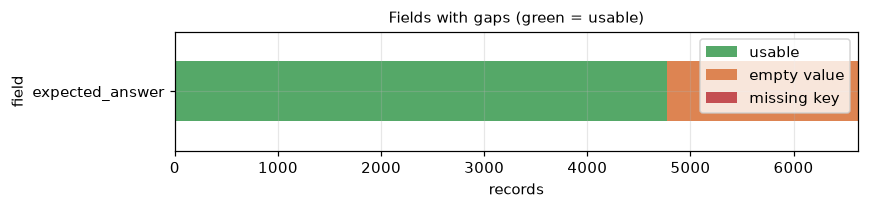

In [8]:
optional = missing[missing["usable %"] < 100]
if len(optional):
    ax = optional.set_index("field")[["usable", "empty value", "missing key"]].plot.barh(
        stacked=True, figsize=(8, max(2, 0.45 * len(optional))),
        color=["#55A868", "#DD8452", "#C44E52"])
    ax.set_title("Fields with gaps (green = usable)", fontsize=10)
    ax.set_xlabel("records")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Every field is populated in every record.")

## 5. Duplicate detection

Duplicates matter twice over: they waste training steps, and an identical
example landing in both train and validation makes the validation loss
meaningless. The trainer deduplicates on the exact `(user, assistant)` pair
**before** splitting, and then removes any example that appears in both files.

In [9]:
def _key(record):
    return json.dumps(record, sort_keys=True, ensure_ascii=False)

whole_record_dupes = len(train_raw) - len({_key(r) for r in train_raw})

question_field = next((f for f in ("interview_question", "question", "output")
                       if field_counts.get(f)), None)
questions = [str(r.get(question_field) or "").strip().lower()
             for r in train_raw if isinstance(r, dict)]
questions = [q for q in questions if q]
question_dupes = len(questions) - len(set(questions))

print(f"identical whole records          : {whole_record_dupes}")
print(f"duplicate '{question_field}' values : {question_dupes}")

if question_dupes:
    repeated = [(q, c) for q, c in Counter(questions).items() if c > 1]
    print()
    print("most repeated:")
    for q, c in sorted(repeated, key=lambda kv: -kv[1])[:5]:
        print(f"   x{c}  {q[:90]}")

identical whole records          : 0
duplicate 'question' values : 0


## 6. Invalid-record detection

`T.build_examples()` validates every record and expands the valid ones into
`(user, assistant)` pairs. Anything it rejects is counted by reason and warned
about — never dropped silently.

Rejection reasons: not a JSON object, no recognised schema, no usable
user/assistant pair for the selected task, user turn under
`MIN_USER_CHARS` characters, assistant turn under `MIN_ASSISTANT_CHARS`.

In [10]:
print(f"MIN_USER_CHARS = {T.MIN_USER_CHARS}    MIN_ASSISTANT_CHARS = {T.MIN_ASSISTANT_CHARS}")
print(f"task = {TASK!r}")
print()

report = T.DatasetReport()
train_examples = T.build_examples(train_raw, TASK, report, "train")
eval_examples = T.build_examples(eval_raw, TASK, report, "validation") if eval_raw else []

train_examples = T.deduplicate_examples(train_examples, report)
if eval_examples:
    eval_examples = T.deduplicate_examples(eval_examples, report)

summary = report.as_dict()
print(json.dumps(summary, indent=2))

MIN_USER_CHARS = 8    MIN_ASSISTANT_CHARS = 8
task = 'both'

{
  "records_read": 7450,
  "examples_built": 12818,
  "duplicate_examples_removed": 0,
  "schemas_detected": {
    "instruction_io": 7450
  },
  "records_dropped": {},
  "examples_per_task": {
    "answer": 5368,
    "question_generation": 7450
  }
}


In [11]:
dropped = summary["records_dropped"]
if dropped:
    ax = pd.Series(dropped).sort_values().plot.barh(figsize=(7, 2.5), color="#C44E52")
    ax.set_title("Records rejected, by reason", fontsize=10)
    ax.set_xlabel("records")
    plt.tight_layout()
    plt.show()
else:
    print("No records were rejected — every record produced at least one valid "
          "training example.")

kept = summary["examples_built"]
print(f"\n{summary['records_read']:,} records -> {kept:,} training examples "
      f"({summary['duplicate_examples_removed']} duplicates removed)")

No records were rejected — every record produced at least one valid training example.

7,450 records -> 12,818 training examples (0 duplicates removed)


### Why the example count exceeds the record count

With `task="both"`, a record that carries **both** a question and an expected
answer yields two supervision signals, so no field goes unused:

* **question generation** — *"Ask me a … question about X"* → the question
* **answer** — the question → the expected answer

A record with no answer (the `ali-alkhars/interviews` half of the corpus) simply
contributes the first of the two.

In [12]:
per_task = pd.Series(summary["examples_per_task"], name="examples").to_frame()
per_task["% of examples"] = (100 * per_task.examples / per_task.examples.sum()).round(1)
per_task

,examples,% of examples
answer,5368,41.9
question_generation,7450,58.1


## 7. Length statistics

Length drives the two settings that decide whether the run fits in a T4's
14.5 GB: `--max_seq_length` and the micro-batch size. Anything longer than
`max_seq_length` is truncated by the trainer, so the p95/p99 are the numbers to
look at — not the mean.

In [13]:
TOKENIZER_CANDIDATES = [
    "meta-llama/Meta-Llama-3-8B",     # the intended base model (gated)
    "mistralai/Mistral-7B-v0.3",      # ungated fallback, comparable tokenizer
]

tokenizer = None
for candidate in TOKENIZER_CANDIDATES:
    try:
        tokenizer = T.load_tokenizer(candidate, T.hf_token())
        TOKENIZER_ID = candidate
        break
    except Exception as exc:
        print(f"{candidate}: unavailable ({type(exc).__name__})")

if tokenizer is None:
    raise RuntimeError("no tokenizer could be loaded; token counts need one")
print(f"\nTokenising with: {TOKENIZER_ID}")

meta-llama/Meta-Llama-3-8B: unavailable (OSError)



Tokenising with: mistralai/Mistral-7B-v0.3


In [14]:
render_prompt, render_completion, PROMPT_STYLE = T.make_renderer(
    tokenizer, "auto", use_system=True)
print(f"prompt style resolved to: {PROMPT_STYLE}")

full_texts = [render_prompt(e["user"]) + render_completion(e["assistant"])
              for e in train_examples]
token_counts = [len(tokenizer(t, add_special_tokens=False)["input_ids"])
                for t in full_texts]

series = pd.Series(token_counts)
stats = pd.Series({
    "examples": len(series),
    "min": series.min(),
    "mean": round(series.mean(), 1),
    "median": series.median(),
    "p90": series.quantile(0.90),
    "p95": series.quantile(0.95),
    "p99": series.quantile(0.99),
    "max": series.max(),
    f"over max_seq_length ({MAX_SEQ_LENGTH})": int((series > MAX_SEQ_LENGTH).sum()),
    "truncated %": round(100 * (series > MAX_SEQ_LENGTH).mean(), 2),
}, name="tokens").to_frame()
stats

prompt style resolved to: plain


,tokens
examples,11398.00
min,58.00
mean,149.70
median,75.00
p90,306.00
p95,322.00
p99,369.03
max,670.00
over max_seq_length (512),14.00
truncated %,0.12


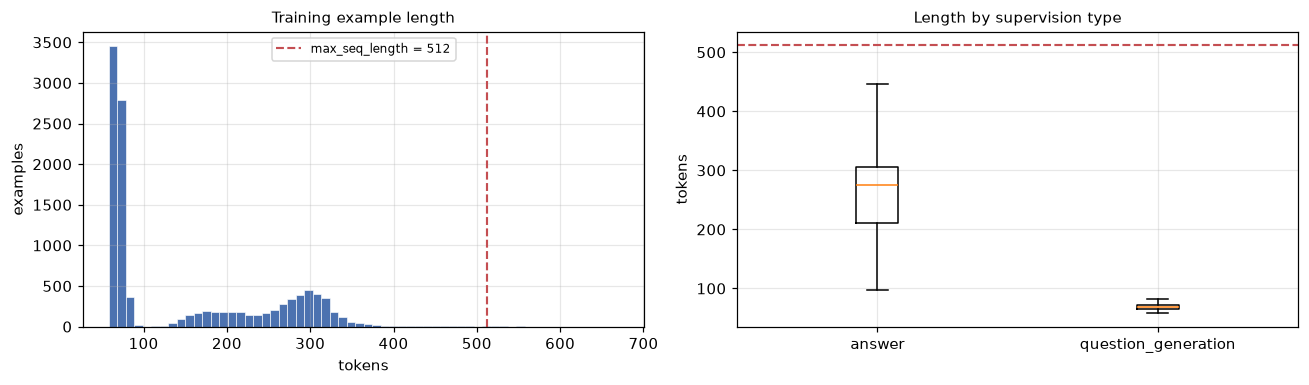

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

axes[0].hist(token_counts, bins=60, color="#4C72B0", edgecolor="white", linewidth=0.4)
axes[0].axvline(MAX_SEQ_LENGTH, color="#C44E52", ls="--", lw=1.4,
                label=f"max_seq_length = {MAX_SEQ_LENGTH}")
axes[0].set_title("Training example length", fontsize=10)
axes[0].set_xlabel("tokens")
axes[0].set_ylabel("examples")
axes[0].legend(fontsize=8)

kinds = sorted({e.get("kind", "unknown") for e in train_examples})
data = [[n for n, e in zip(token_counts, train_examples) if e.get("kind") == k]
        for k in kinds]
axes[1].boxplot([d for d in data if d], showfliers=False,
                tick_labels=[k for k, d in zip(kinds, data) if d])
axes[1].axhline(MAX_SEQ_LENGTH, color="#C44E52", ls="--", lw=1.4)
axes[1].set_title("Length by supervision type", fontsize=10)
axes[1].set_ylabel("tokens")

fig.tight_layout()
plt.show()

Answer examples are the long ones — a question is a single sentence, an expected
answer is a paragraph. If the truncation percentage above is uncomfortable, the
options are to raise `--max_seq_length` (costs VRAM, roughly linearly) or to
train question generation only with `--task question_generation`.

## 8. Train / validation split

When the corpus ships its own validation file, that file is used and the trainer
additionally removes any example that also appears in train. When it does not
(or the file is empty — `dataset/training/val.json` currently is), the trainer
falls back to a seeded `--validation_split` of the training examples.

Deduplication happens **before** the split, so an example cannot straddle it.
The seed makes the split byte-for-byte reproducible.

In [16]:
import random

if eval_examples:
    train_keys = {(e["user"], e["assistant"]) for e in train_examples}
    leaked = [e for e in eval_examples if (e["user"], e["assistant"]) in train_keys]
    split_train = train_examples
    split_eval = [e for e in eval_examples if (e["user"], e["assistant"]) not in train_keys]
    strategy = f"validation file supplied ({provenance.get('eval_file', 'n/a')})"
else:
    shuffled = list(train_examples)
    random.Random(SEED).shuffle(shuffled)
    cut = int(len(shuffled) * VALIDATION_SPLIT)
    if cut == 0 and len(shuffled) >= 10 and VALIDATION_SPLIT > 0:
        cut = 1
    split_eval, split_train = shuffled[:cut], shuffled[cut:]
    leaked = []
    strategy = f"in-script {1 - VALIDATION_SPLIT:.0%}/{VALIDATION_SPLIT:.0%} split, seed {SEED}"

overlap = ({(e["user"], e["assistant"]) for e in split_train}
           & {(e["user"], e["assistant"]) for e in split_eval})

print(f"strategy            : {strategy}")
print(f"training examples   : {len(split_train):,}")
print(f"validation examples : {len(split_eval):,}")
print(f"leaked examples removed from validation: {len(leaked)}")
print(f"train/validation overlap after split   : {len(overlap)}")
assert not overlap, "train/validation leakage detected"
print("\nNo leakage.")

strategy            : validation file supplied (C:\Users\gihan\Documents\ai-interview-system\ml-service\dataset\processed\question_generator\validation.jsonl)
training examples   : 11,398
validation examples : 1,420
leaked examples removed from validation: 0
train/validation overlap after split   : 0

No leakage.


In [17]:
distribution = pd.DataFrame({
    "train": pd.Series(Counter(e.get("kind", "unknown") for e in split_train)),
    "validation": pd.Series(Counter(e.get("kind", "unknown") for e in split_eval)),
}).fillna(0).astype(int)
distribution.loc["TOTAL"] = distribution.sum()
distribution["train %"] = (100 * distribution["train"]
                           / max(distribution.loc["TOTAL", "train"], 1)).round(1)
distribution["validation %"] = (100 * distribution["validation"]
                                / max(distribution.loc["TOTAL", "validation"], 1)).round(1)
distribution

,train,validation,train %,validation %
question_generation,6625,825,58.1,58.1
answer,4773,595,41.9,41.9
TOTAL,11398,1420,100.0,100.0


## 9. Final dataset format

TRL is given two columns, `prompt` and `completion`, rather than one blob of
text. That enables **completion-only loss**: the prompt tokens are masked out of
the loss so the model is trained to *produce* the answer, not to reproduce the
instruction it was given.

The prompt layout depends on the base model:

* **`plain`** — for base checkpoints such as `Meta-Llama-3-8B`, which have no
  chat template:

  ```text
  <system prompt>

  User:
  <request>

  Assistant:
  <target>
  ```

* **`chat`** — for `*-Instruct` checkpoints, using the tokenizer's own
  `chat_template` so the special tokens match what the model saw in its own
  instruction tuning.

`--prompt_style auto` (the default) picks between them by looking for a chat
template on the tokenizer.

In [18]:
completion_only = True
try:
    from trl import SFTConfig
    completion_only = "completion_only_loss" in T.accepted_fields(SFTConfig)
    print(f"installed TRL supports completion_only_loss: {completion_only}")
except ImportError:
    print("trl is not installed here; the trainer would fall back to a single "
          "'text' column with loss over the whole sequence")

columns = ({"prompt": "rendered instruction (masked out of the loss)",
            "completion": "target text + EOS (the only tokens scored)"}
           if completion_only else
           {"text": "prompt + completion concatenated; loss over everything"})
pd.Series(columns, name="meaning").to_frame()

installed TRL supports completion_only_loss: True


,meaning
prompt,rendered instruction (masked out of the loss)
completion,target text + EOS (the only tokens scored)


## 10. Sample formatted training examples

The strings below are exactly what reaches the model — no summarising, no
paraphrasing. Note that every assistant turn is source text copied verbatim.

In [19]:
shown = set()
for example in split_train:
    kind = example.get("kind", "unknown")
    if kind in shown:
        continue
    shown.add(kind)
    print("=" * 92)
    print(f"SUPERVISION TYPE: {kind}    (schema: {example['schema']})")
    print("=" * 92)
    print("--- PROMPT (masked out of the loss) " + "-" * 55)
    print(render_prompt(example["user"]))
    print("--- COMPLETION (scored) " + "-" * 67)
    print(render_completion(example["assistant"])[:700])
    print()
    if len(shown) >= 3:
        break

SUPERVISION TYPE: question_generation    (schema: instruction_io)
--- PROMPT (masked out of the loss) -------------------------------------------------------
You are a senior software engineering interviewer. You ask precise technical interview questions and give accurate, concise technical answers.

User:
Generate a technical interview question.
Domain: Frontend Development
Difficulty: Beginner

Assistant:

--- COMPLETION (scored) -------------------------------------------------------------------
What is Angular Framework?</s>

SUPERVISION TYPE: answer    (schema: instruction_io)
--- PROMPT (masked out of the loss) -------------------------------------------------------
You are a senior software engineering interviewer. You ask precise technical interview questions and give accurate, concise technical answers.

User:
How Godly does an object need to be before it becomes unholy?

Assistant:

--- COMPLETION (scored) -------------------------------------------------------------------
Ac

In [20]:
preview = pd.DataFrame([{
    "kind": e.get("kind"),
    "schema": e["schema"],
    "user": e["user"].replace("\n", " ⏎ ")[:70],
    "assistant": e["assistant"].replace("\n", " ⏎ ")[:70],
} for e in split_train[:8]])
preview

,kind,schema,user,assistant
0,question_generation,instruction_io,Generate a technical interview question. ⏎ Domain: Frontend Developmen,What is Angular Framework?
1,question_generation,instruction_io,Generate a technical interview question. ⏎ Domain: Frontend Developmen,What is the difference between AngularJS and Angular?
2,question_generation,instruction_io,Generate a technical interview question. ⏎ Domain: Frontend Developmen,What are the key components of Angular?
3,question_generation,instruction_io,Generate a technical interview question. ⏎ Domain: Frontend Developmen,What are the differences between Component and Directive?
4,question_generation,instruction_io,Generate a technical interview question. ⏎ Domain: Frontend Developmen,What is a template?
5,question_generation,instruction_io,Generate a technical interview question. ⏎ Domain: Frontend Developmen,What is a module?
6,question_generation,instruction_io,Generate a technical interview question. ⏎ Domain: Frontend Developmen,What is a data binding?
7,question_generation,instruction_io,Generate a technical interview question. ⏎ Domain: Frontend Developmen,What is Angular CLI?


## 11. Dataset statistics

The summary that goes in the dissertation's dataset chapter. Every figure is
computed above rather than typed in.

In [21]:
def token_stats(examples):
    if not examples:
        return {"examples": 0}
    counts = [len(tokenizer(render_prompt(e["user"]) + render_completion(e["assistant"]),
                            add_special_tokens=False)["input_ids"])
              for e in examples]
    s = pd.Series(counts)
    return {
        "examples": len(s),
        "tokens_mean": round(s.mean(), 1),
        "tokens_median": int(s.median()),
        "tokens_p95": int(s.quantile(0.95)),
        "tokens_max": int(s.max()),
        "tokens_total": int(s.sum()),
        f"over_{MAX_SEQ_LENGTH}": int((s > MAX_SEQ_LENGTH).sum()),
    }

final_stats = pd.DataFrame({
    "train": token_stats(split_train),
    "validation": token_stats(split_eval),
}).fillna(0)
final_stats

,train,validation
examples,11398.0,1420.0
tokens_mean,149.7,149.5
tokens_median,75.0,75.0
tokens_p95,322.0,322.0
tokens_max,670.0,502.0
tokens_total,1705782.0,212249.0
over_512,14.0,0.0


In [22]:
effective_batch = 1 * 8   # --batch_size 1 --gradient_accumulation_steps 8
epochs = 3
steps_per_epoch = len(split_train) / effective_batch

overview = pd.Series({
    "Source dataset": DATASET_NAME,
    "Source path": str(DATASET_PATH.relative_to(ML_SERVICE)),
    "Raw records read": summary["records_read"],
    "Records rejected": sum(summary["records_dropped"].values()),
    "Duplicates removed": summary["duplicate_examples_removed"],
    "Training examples": len(split_train),
    "Validation examples": len(split_eval),
    "Supervision types": ", ".join(sorted({e.get("kind", "?") for e in split_train})),
    "Tokenizer": TOKENIZER_ID,
    "Prompt style": PROMPT_STYLE,
    "Completion-only loss": completion_only,
    "Max sequence length": MAX_SEQ_LENGTH,
    "Effective batch size": effective_batch,
    "Optimiser steps / epoch": int(steps_per_epoch),
    "Optimiser steps total": int(steps_per_epoch * epochs),
    "Seed": SEED,
}, name="value").to_frame()
overview

,value
Source dataset,question_generator (JSONL)
Source path,dataset\processed\question_generator
Raw records read,7450
Records rejected,0
Duplicates removed,0
Training examples,11398
Validation examples,1420
Supervision types,"answer, question_generation"
Tokenizer,mistralai/Mistral-7B-v0.3
Prompt style,plain


The optimiser-step count is the number that predicts wall-clock time. On a
Tesla T4, an 8B QLoRA step at `max_seq_length=512` with an effective batch of 8
runs on the order of a few seconds, so multiply accordingly before committing to
three epochs in one Colab session — and see the timing note in section 12.

## 12. Export of the final training dataset

The trainer regenerates these examples deterministically from the source corpus
every run, so this export is a **reproducibility snapshot** for the dissertation
and for inspection — not a new source of truth.

It is written to a fresh directory. No raw dataset is touched, overwritten or
deleted.

In [23]:
EXPORT_DIR = ML_SERVICE / "dataset" / "training" / "qlora_sft"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def export(examples, filename):
    path = EXPORT_DIR / filename
    with path.open("w", encoding="utf-8") as fh:
        for e in examples:
            fh.write(json.dumps({
                "prompt": render_prompt(e["user"]),
                "completion": render_completion(e["assistant"]),
                "kind": e.get("kind"),
                "source_schema": e["schema"],
            }, ensure_ascii=False) + "\n")
    return path, path.stat().st_size

written = []
for examples, filename in ((split_train, "train.jsonl"), (split_eval, "validation.jsonl")):
    path, size = export(examples, filename)
    written.append({"file": str(path.relative_to(ML_SERVICE)),
                    "examples": len(examples), "size_MB": round(size / 1e6, 2)})

manifest = {
    "generated_by": "notebooks/01_qlora_data_preparation.ipynb",
    "source_dataset": str(DATASET_PATH.relative_to(ML_SERVICE)),
    "task": TASK,
    "tokenizer": TOKENIZER_ID,
    "prompt_style": PROMPT_STYLE,
    "max_seq_length": MAX_SEQ_LENGTH,
    "seed": SEED,
    "validation_split": VALIDATION_SPLIT,
    "counts": {"train": len(split_train), "validation": len(split_eval)},
    "dataset_report": summary,
    "library_versions": T.library_versions(),
}
(EXPORT_DIR / "manifest.json").write_text(
    json.dumps(manifest, indent=2, default=str), encoding="utf-8")

written.append({"file": str((EXPORT_DIR / 'manifest.json').relative_to(ML_SERVICE)),
                "examples": "-",
                "size_MB": round((EXPORT_DIR / "manifest.json").stat().st_size / 1e6, 3)})
pd.DataFrame(written)

,file,examples,size_MB
0,dataset\training\qlora_sft\train.jsonl,11398,8.730
1,dataset\training\qlora_sft\validation.jsonl,1420,1.090
2,dataset\training\qlora_sft\manifest.json,-,0.001


In [24]:
# Read the first exported line back to prove the file is valid JSONL.
with (EXPORT_DIR / "train.jsonl").open(encoding="utf-8") as fh:
    first = json.loads(fh.readline())
print("Round-trip check — first exported record:")
print(json.dumps({k: (v[:220] + "..." if isinstance(v, str) and len(v) > 220 else v)
                  for k, v in first.items()}, indent=2, ensure_ascii=False))

Round-trip check — first exported record:
{
  "prompt": "You are a senior software engineering interviewer. You ask precise technical interview questions and give accurate, concise technical answers.\n\nUser:\nGenerate a technical interview question.\nDomain: Frontend Development\n...",
  "completion": "What is Angular Framework?</s>",
  "kind": "question_generation",
  "source_schema": "instruction_io"
}


## Next step — training

Preparation stops here. Nothing above starts a fine-tune.

```bash
# Colab, once per session
pip install -q -U transformers datasets accelerate peft trl bitsandbytes
huggingface-cli login          # Meta Llama 3 is a gated repository

cd ml-service

# validate the pipeline without touching the GPU (seconds)
python training/train_qlora.py --dry_run

# the real run
python training/train_qlora.py \
    --base_model meta-llama/Meta-Llama-3-8B \
    --dataset dataset/processed/question_generator \
    --output_dir training/output/interview_llm \
    --epochs 3 --batch_size 1 --gradient_accumulation_steps 8 \
    --max_seq_length 512
```

The LoRA adapter, `metrics.json`, `training_args.json` and
`experiment_metadata.json` all land in `training/output/interview_llm/`.